# 00 — Video to Dataset (Hand)

Converts videos you recorded yourself (Desktop "Data Recorder") into
`dataset.npz`. Each `recordings/*.mp4` now has a paired `*_depth.npz` --
real Orbbec depth, saved alongside the video when you recorded it -- so
this notebook fuses real depth per frame instead of trusting MediaPipe's
own scale-ambiguous z guess.

**Requires:** recordings made with the updated "Data Recorder" (saves
`_depth.npz` next to the `.mp4` automatically). Older recordings without
a depth file still work, just fall back to MediaPipe's raw z for that
video, same as before.


## Step 1 — Videos

Every `.mp4` in `../recordings/` with a matching `*_depth.npz`.

In [1]:
import os
import sys
import glob

import cv2
import numpy as np
import matplotlib.pyplot as plt

_SCRIPTS = os.path.abspath('..')
sys.path.insert(0, _SCRIPTS)

from data_processing.feature_extractor import FeatureExtractor, FEATURE_DIM, NUM_LANDMARKS
from data_processing.preprocessor import Preprocessor
from motion_mapping import fuse_depth
import depth_calibration

def depth_path_for(video_path):
    """session.mp4 -> session_depth.npz -- matches Data Recorder's naming."""
    root, _ = os.path.splitext(video_path)
    return root + '_depth.npz'

VIDEO_DIR   = '../recordings'
OUT_PATH    = '../dataset.npz'
WINDOW_SIZE = 30

def _sort_key(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    return (0, int(stem)) if stem.isdigit() else (1, stem)

VIDEO_PATHS = sorted(glob.glob(os.path.join(VIDEO_DIR, '*.mp4')), key=_sort_key)

_calib = depth_calibration.load()
print(f'Depth calibration : {"true = (reported - %.2f) / %.5f" % (_calib[1], _calib[0]) if _calib else "NONE SAVED"}')
print(f'Found {len(VIDEO_PATHS)} video(s) in {os.path.abspath(VIDEO_DIR)}:')
for _vp in VIDEO_PATHS:
    dp = depth_path_for(_vp)
    if os.path.exists(dp):
        _, _note = depth_calibration.load_depth_stack(dp)
    else:
        _note = 'no depth file (will use MediaPipe z)'
    print(f'  {_vp}  ->  {_note}')

if _calib is None:
    print('\n*** WARNING: no calibration saved, so the depth in these recordings is')
    print('    the sensor\'s raw mis-scaled output (roughly 37-83 for a whole room).')
    print('    Fusing it produces worse features than MediaPipe\'s own z. Either run')
    print('    the Desktop "Depth Calibration" tool first, or set USE_DEPTH = False')
    print('    below to build the dataset from MediaPipe z alone.')

/home/user_02/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Depth calibration : true = (reported - -1.00) / 0.10000
Found 5 video(s) in /home/user_02/Desktop/ros2_ws/src/robot_arm/scripts/recordings:
  ../recordings/1.mp4  ->  already calibrated at capture time
  ../recordings/2.mp4  ->  already calibrated at capture time
  ../recordings/3.mp4  ->  already calibrated at capture time
  ../recordings/4.mp4  ->  already calibrated at capture time
  ../recordings/5.mp4  ->  already calibrated at capture time


## Step 2 — Load MediaPipe Hands

In [2]:
import mediapipe as mp

BaseOptions           = mp.tasks.BaseOptions
HandLandmarker        = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
RunningMode           = mp.tasks.vision.RunningMode

MODEL_PATH = os.path.join(_SCRIPTS, 'perception', 'hand_landmarker.task')
assert os.path.exists(MODEL_PATH), f'Model not found: {MODEL_PATH}'

opts = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.VIDEO,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3,
    min_tracking_confidence=0.3,
    num_hands=1,
)
print('HandLandmarker options ready (a fresh landmarker is created per video below).')


HandLandmarker options ready (a fresh landmarker is created per video below).


## Step 3 — Detect hand landmarks per frame, fuse real depth

For each detected frame, if a depth file exists for this video, look up
the matching depth frame by index and call `fuse_depth()` -- the exact
same function the live pipeline uses -- replacing MediaPipe's x/y/z with
real calibrated camera-space metres.


In [3]:
# Fuse real depth only when it is actually trustworthy. Uncalibrated depth
# from this sensor is worse than MediaPipe's own z, so the default follows
# whether a calibration exists; set it to True/False by hand to force either
# arm of the depth comparison.
USE_DEPTH = depth_calibration.load() is not None
print(f'USE_DEPTH = {USE_DEPTH}\n')

raw_landmark_frames_by_video = []  # one list of (21, 5) arrays per video
total_frame_idx = 0
total_skipped = 0
total_depth_fused = 0

for VIDEO_PATH in VIDEO_PATHS:
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS) or 15.0
    frame_interval_ms = 1000.0 / fps

    depth_path = depth_path_for(VIDEO_PATH)
    depth_stack = None
    if USE_DEPTH and os.path.exists(depth_path):
        # Corrects raw recordings, leaves already-corrected ones alone.
        depth_stack, _ = depth_calibration.load_depth_stack(depth_path)

    landmarker = HandLandmarker.create_from_options(opts)

    video_frames = []
    ts_ms = 0
    frame_idx = 0
    skipped = 0
    fused = 0

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = landmarker.detect_for_video(mp_img, int(ts_ms))

        if result.hand_landmarks:
            lms = result.hand_landmarks[0]
            arr = np.array([[lm.x, lm.y, lm.z, 1.0, 1.0] for lm in lms], dtype=np.float32)  # (21, 5)
            if depth_stack is not None and frame_idx < len(depth_stack):
                arr = fuse_depth(arr, depth_stack[frame_idx])
                fused += 1
            video_frames.append(arr)
        else:
            skipped += 1

        frame_idx += 1
        ts_ms += frame_interval_ms

    cap.release()
    landmarker.close()

    raw_landmark_frames_by_video.append(video_frames)
    total_frame_idx += frame_idx
    total_skipped += skipped
    total_depth_fused += fused
    print(f'{VIDEO_PATH}: read {frame_idx} frames, hand detected in {len(video_frames)}, '
          f'depth-fused {fused}, skipped {skipped}')

print(f'Total frames read   : {total_frame_idx}')
print(f'Hand detected in    : {sum(len(v) for v in raw_landmark_frames_by_video)} frames')
print(f'Depth-fused         : {total_depth_fused} frames')
print(f'Skipped (no hand)   : {total_skipped} frames')

USE_DEPTH = True



I0000 00:00:1788605745.042586  171893 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788605745.045274  171925 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1788605745.060419  171895 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788605745.069107  171909 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788605745.101755  171895 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


../recordings/1.mp4: read 665 frames, hand detected in 187, depth-fused 187, skipped 478


I0000 00:00:1788605759.712695  171974 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788605759.713319  171993 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
W0000 00:00:1788605759.727646  171983 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788605759.735620  171990 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


../recordings/2.mp4: read 655 frames, hand detected in 206, depth-fused 206, skipped 449


...

../recordings/3.mp4: read 661 frames, hand detected in 263, depth-fused 263, skipped 398


I0000 00:00:1788605787.612857  172078 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788605787.613494  172097 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
W0000 00:00:1788605787.626675  172080 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788605787.631628  172094 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


../recordings/4.mp4: read 654 frames, hand detected in 181, depth-fused 181, skipped 473


I0000 00:00:1788605802.404905  172129 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788605802.405716  172148 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.4), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
W0000 00:00:1788605802.416384  172131 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788605802.421315  172142 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


../recordings/5.mp4: read 659 frames, hand detected in 249, depth-fused 249, skipped 410
Total frames read   : 3294
Hand detected in    : 1086 frames
Depth-fused         : 1086 frames
Skipped (no hand)   : 2208 frames


## Step 4 — Feature extraction + sliding windows

In [4]:
extractor = FeatureExtractor()

samples_X, samples_y = [], []

for video_frames in raw_landmark_frames_by_video:
    preprocessor = Preprocessor(window_size=WINDOW_SIZE)
    buffer = []

    for lm_arr in video_frames:
        features = extractor.extract(lm_arr)               # (63,)
        norm = preprocessor._normalize(features, lm_arr)    # same normalisation as live
        buffer.append(norm)

        if len(buffer) == WINDOW_SIZE + 1:
            seq = np.array(buffer[:-1], dtype=np.float32)
            nxt = buffer[-1]
            samples_X.append(seq)
            samples_y.append(nxt)
            buffer.pop(0)

print(f'FEATURE_DIM   : {FEATURE_DIM}')
print(f'Samples built : {len(samples_X)}')


FEATURE_DIM   : 63
Samples built : 936


## Step 5 — Save `dataset.npz`

In [5]:
if len(samples_X) < 10:
    print(f'Only {len(samples_X)} samples -- record a longer / more active video.')
else:
    X = np.array(samples_X, dtype=np.float32)
    y = np.array(samples_y, dtype=np.float32)
    np.savez(OUT_PATH, X=X, y=y)
    print(f'Saved: X={X.shape}  y={y.shape}  ->  {os.path.abspath(OUT_PATH)}')


Saved: X=(936, 30, 63)  y=(936, 63)  ->  /home/user_02/Desktop/ros2_ws/src/robot_arm/scripts/dataset.npz


## Step 6 — Sanity-check: fingertip trajectory plot

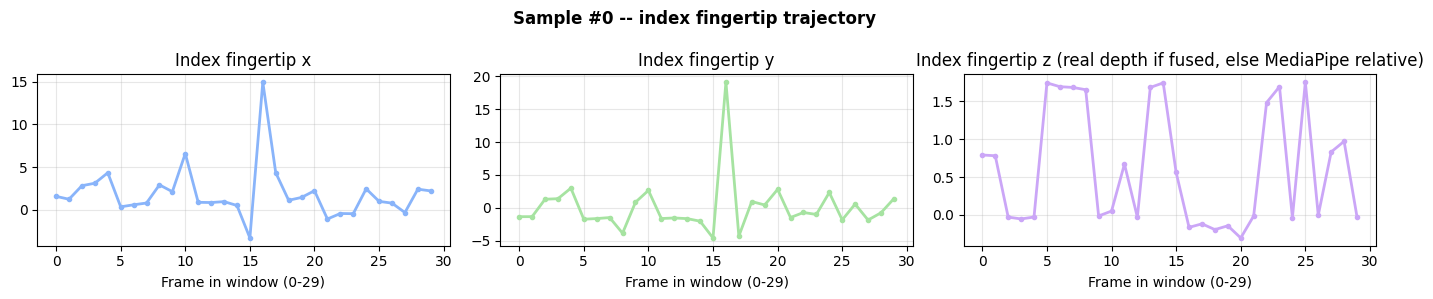

In [6]:
if len(samples_X) >= 10:
    sample = X[0]
    FINGERTIP_IDX = 8
    tip_xyz = sample[:, FINGERTIP_IDX*3 : FINGERTIP_IDX*3 + 3]

    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    labels = ['x', 'y', 'z (real depth if fused, else MediaPipe relative)']
    colors = ['#89b4fa', '#a6e3a1', '#cba6f7']
    for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
        ax.plot(tip_xyz[:, i], color=color, linewidth=2, marker='o', markersize=3)
        ax.set_title(f'Index fingertip {label}')
        ax.set_xlabel('Frame in window (0-29)')
        ax.grid(alpha=0.3)
    plt.suptitle('Sample #0 -- index fingertip trajectory', fontweight='bold')
    plt.tight_layout()
    plt.show()


## Summary

- [ ] Depth-fused count close to hand-detected count (check Step 3 output --
      low means recordings are missing `_depth.npz`, so those videos fell
      back to MediaPipe's relative z)
- [ ] `X.shape == (N, 30, 63)`, `y.shape == (N, 63)`
- [ ] Fingertip plot looks like motion, not noise

**Next:** `01_pose_video_to_dataset.ipynb`
